In [37]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [38]:
REPO_ROOT = Path.home() / "EASM"
PROCESSED_DIR = REPO_ROOT / "data"
OUTPUT_DIR = REPO_ROOT / "outputs" / "som_u850"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [39]:
# =========================================================
# 0) input paths
# =========================================================
som_csv = OUTPUT_DIR / "som_daily_assignment.csv"
olr_file = PROCESSED_DIR / "olr_jja_1982_2025.nc"
out_fig = OUTPUT_DIR / "olr_anom_node_composites_sig2.png"

In [40]:
# =========================================================
# 1) SOM 일별 할당표 읽기
# =========================================================
df = pd.read_csv(som_csv)
df["date"] = pd.to_datetime(df["date"]).dt.normalize()

# node 1~9만 유지
df = df[df["node"].between(1, 9)].copy()
df = df.sort_values("date").drop_duplicates(subset="date")

In [41]:
# =========================================================
# 2) OLR 자료 읽기
# =========================================================
ds = xr.open_dataset(olr_file)
olr = ds["olr"]  # (time, lat, lon) 가정

# 좌표명 통일
rename_dict = {}
if "latitude" in olr.dims:
    rename_dict["latitude"] = "lat"
if "longitude" in olr.dims:
    rename_dict["longitude"] = "lon"
if rename_dict:
    olr = olr.rename(rename_dict)

# 길이 1짜리 차원 제거 (예: zlev, level 등)
olr = olr.squeeze(drop=True)

In [42]:
clim = olr.groupby("time.dayofyear").mean("time")
olr = olr.groupby("time.dayofyear") - clim

In [43]:
# =========================================================
# 3) 시간축을 pandas datetime으로 통일
# =========================================================
olr_time = pd.to_datetime(olr["time"].values).normalize()
olr = olr.assign_coords(time=olr_time)

In [44]:
# =========================================================
# 4) CSV와 NetCDF의 공통 날짜만 남김
# =========================================================
common_time = np.intersect1d(olr["time"].values, df["date"].values)

print("len(olr time)   =", olr.sizes["time"])
print("len(df date)    =", len(df))
print("len(common_time)=", len(common_time))

if len(common_time) == 0:
    raise ValueError("공통 날짜가 없습니다. olr time과 CSV date를 확인하세요.")

olr_sel = olr.sel(time=common_time)

node_map = df.set_index("date")["node"].reindex(pd.to_datetime(common_time))

valid = ~node_map.isna().to_numpy()
olr_sel = olr_sel.isel(time=valid)
node_vals = node_map.to_numpy()[valid].astype(int)

print("len(olr_sel time) =", olr_sel.sizes["time"])
print("len(node_vals)    =", len(node_vals))

if olr_sel.sizes["time"] == 0:
    raise ValueError("olr_sel의 time 길이가 0입니다.")

len(olr time)   = 4048
len(df date)    = 4048
len(common_time)= 4048
len(olr_sel time) = 4048
len(node_vals)    = 4048


In [45]:
# =========================================================
# 5) node를 xarray coordinate로 부여
# =========================================================
olr_sel = olr_sel.assign_coords(node=("time", node_vals))

In [46]:
# =========================================================
# 6) node별 composite 평균 / 표준편차 / 표본수
# =========================================================
comp = olr_sel.groupby("node").mean(dim="time")
std = olr_sel.groupby("node").std(dim="time")
n = olr_sel.groupby("node").count(dim="time")

# node 1~9 모두 유지
nodes_all = np.arange(1, 10)
comp = comp.reindex(node=nodes_all)
std = std.reindex(node=nodes_all)
n = n.reindex(node=nodes_all)

# 표준오차
se = std / np.sqrt(n)

In [47]:
# =========================================================
# 7) 2-sigma significance mask
#    |mean| >= 2 * SE
# =========================================================
sig2 = (np.abs(comp) >= 2.0 * se).fillna(False)

print(comp)
print(n)

<xarray.DataArray 'olr' (node: 9, lat: 73, lon: 144)> Size: 378kB
array([[[-0.18031643, -0.1756631 , -0.19287221, ..., -0.19670542,
         -0.19411133, -0.19476768],
        [-0.32388067, -0.36914426, -0.37149104, ..., -0.3277172 ,
         -0.34130865, -0.35628664],
        [-0.33559588, -0.3139293 , -0.31311533, ..., -0.30194056,
         -0.30607572, -0.3053149 ],
        ...,
        [ 0.56223005,  0.5546787 ,  0.6468091 , ...,  0.46901926,
          0.3960378 ,  0.5038487 ],
        [ 0.05725966,  0.00232607,  0.05540048, ...,  0.06595758,
          0.11941762,  0.1480399 ],
        [ 0.09942335,  0.08709376,  0.11385465, ...,  0.07707211,
          0.09990786,  0.11063129]],

       [[ 0.28620264,  0.27994516,  0.29175127, ...,  0.28467944,
          0.28724614,  0.2941327 ],
        [ 0.15099828,  0.17529574,  0.2120771 , ...,  0.18279445,
          0.12661374,  0.21345071],
        [-0.02732382, -0.04151419, -0.02972911, ..., -0.06927347,
         -0.0460913 , -0.06160686],
.

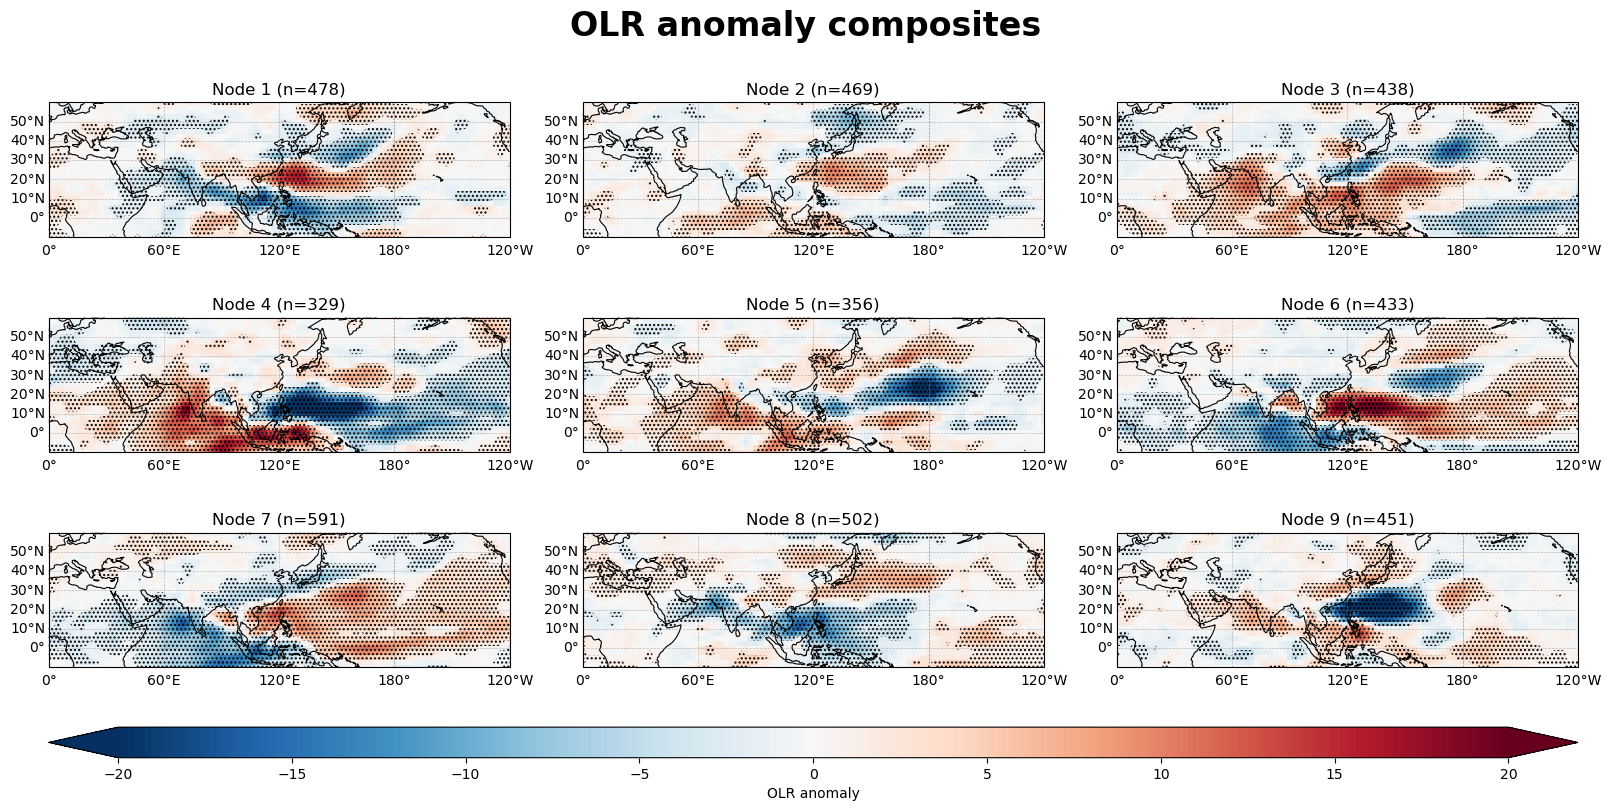

In [48]:
# =========================================================
# 8) Plot
# =========================================================
proj = ccrs.PlateCarree(central_longitude=180)

fig, axes = plt.subplots(
    3, 3, figsize=(16, 8), layout="constrained", subplot_kw={"projection": proj}
)

pcm = None

for i, ax in enumerate(axes.flat, start=1):
    ax.set_extent([0, 240, -10, 60], crs=ccrs.PlateCarree())

    da = comp.sel(node=i).squeeze(drop=True)
    mask = sig2.sel(node=i).squeeze(drop=True)

    if np.isfinite(da.values).any():
        pcm = da.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            add_colorbar=False,
            cmap="RdBu_r",
            vmin=-20,
            vmax=20,
            extend="both",
        )

        # stipple/hatching
        ax.contourf(
            da["lon"].values,
            da["lat"].values,
            mask.astype(int).values,
            levels=[0.5, 1.5],
            hatches=["...."],
            colors="none",
            transform=ccrs.PlateCarree(),
        )

    ax.coastlines(linewidth=0.8)
    gl = ax.gridlines(
        draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--"
    )
    gl.top_labels = False
    gl.right_labels = False
    ax.set_title(f"Node {i} (n={int(np.nanmax(n.sel(node=i).values))})")

fig.suptitle("OLR anomaly composites", fontsize=24, fontweight="bold")

# 공통 colorbar
if pcm is not None:
    cbar = fig.colorbar(
        pcm,
        ax=axes.ravel().tolist(),
        orientation="horizontal",
        fraction=0.05,
        pad=0.06,
        aspect=50,
        extend="both",
    )
    cbar.set_label("OLR anomaly")

plt.savefig(out_fig, dpi=144, bbox_inches="tight")
plt.show()